# Ultimate Revenue Optimization Project
## Logistic Regression | Revenue Uplift Simulation | A/B Testing | Driver Impact Analysis | Testing Hypothesis

## Objective
To fine the relationship of the revenue with the payment method used.

## Methodology
<ol type="a">
    <li>The use of descriptive statistics and hypothesis testing to find the effect of the fare used.</li>
    <li>Gather insights relative to the fares used whether with the credit cards or by hand payment i.e., with cash.</li>
</ol>

## Research questions
* Is there a relationship between total fare amount and payment type?
* Can we nudge customers towards payment methods that yield higher revenue for drivers, without negatively impacting customer experience?

## Importing the necessary python libraries

In [143]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import statsmodels.api as sm
from warnings import filterwarnings
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

plt.rcParams['figure.figsize'] = (8,5)

filterwarnings('ignore')

## Reading the dataset

In [144]:
df = pd.read_csv('/content/yellow_tripdata_2020-01.csv')
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.20,1,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.20,1,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.60,1,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.80,1,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.00,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283799,2,2020-01-02 18:54:09,2020-01-02 19:09:04,1,1.54,1,N,230,143,2,11.0,1.0,0.5,0.00,0.0,0.3,15.30,2.5
283800,1,2020-01-02 18:18:26,2020-01-02 18:42:31,1,4.50,1,N,161,260,4,19.0,3.5,0.5,0.00,0.0,0.3,23.30,2.5
283801,2,2020-01-02 18:31:07,2020-01-02 18:40:08,1,0.95,1,N,163,142,1,7.0,1.0,0.5,1.10,0.0,0.3,12.40,2.5
283802,2,2020-01-02 18:42:27,2020-01-02 18:46:51,1,0.70,1,N,142,143,2,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5


## EDA (Exploratory Data Analysis)

### Giving correct dtypes

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283804 entries, 0 to 283803
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               283804 non-null  int64  
 1   tpep_pickup_datetime   283804 non-null  object 
 2   tpep_dropoff_datetime  283804 non-null  object 
 3   passenger_count        283804 non-null  int64  
 4   trip_distance          283804 non-null  float64
 5   RatecodeID             283804 non-null  int64  
 6   store_and_fwd_flag     283804 non-null  object 
 7   PULocationID           283804 non-null  int64  
 8   DOLocationID           283804 non-null  int64  
 9   payment_type           283804 non-null  int64  
 10  fare_amount            283803 non-null  float64
 11  extra                  283803 non-null  float64
 12  mta_tax                283803 non-null  float64
 13  tip_amount             283803 non-null  float64
 14  tolls_amount           283803 non-nu

In [146]:
df.select_dtypes(include='object')

,tpep_pickup_datetime,tpep_dropoff_datetime,store_and_fwd_flag
0,2020-01-01 00:28:15,2020-01-01 00:33:03,N
1,2020-01-01 00:35:39,2020-01-01 00:43:04,N
2,2020-01-01 00:47:41,2020-01-01 00:53:52,N
3,2020-01-01 00:55:23,2020-01-01 01:00:14,N
4,2020-01-01 00:01:58,2020-01-01 00:04:16,N
...,...,...,...
283799,2020-01-02 18:54:09,2020-01-02 19:09:04,N
283800,2020-01-02 18:18:26,2020-01-02 18:42:31,N
283801,2020-01-02 18:31:07,2020-01-02 18:40:08,N
283802,2020-01-02 18:42:27,2020-01-02 18:46:51,N


In [147]:
type_mappings = {
    'tpep_pickup_datetime': 'datetime64[ns]',
    'tpep_dropoff_datetime': 'datetime64[ns]',
    'store_and_fwd_flag': 'string',
}
df = df.astype(type_mappings)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283804 entries, 0 to 283803
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               283804 non-null  int64         
 1   tpep_pickup_datetime   283804 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  283804 non-null  datetime64[ns]
 3   passenger_count        283804 non-null  int64         
 4   trip_distance          283804 non-null  float64       
 5   RatecodeID             283804 non-null  int64         
 6   store_and_fwd_flag     283804 non-null  string        
 7   PULocationID           283804 non-null  int64         
 8   DOLocationID           283804 non-null  int64         
 9   payment_type           283804 non-null  int64         
 10  fare_amount            283803 non-null  float64       
 11  extra                  283803 non-null  float64       
 12  mta_tax                283803 non-null  floa

### Filling `NaN`

In [148]:
df.isna().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


In [149]:
df['VendorID'].value_counts()

,count
VendorID,
2,195892
1,87912


In [150]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')

In [151]:
df.dtypes

,0
VendorID,int64
tpep_pickup_datetime,datetime64[ns]
tpep_dropoff_datetime,datetime64[ns]
passenger_count,int64
trip_distance,float64
RatecodeID,int64
store_and_fwd_flag,string[python]
PULocationID,int64
DOLocationID,int64
payment_type,int64


In [152]:
# Fill NaN with the mode (most frequent value)
df['VendorID'].fillna(df['VendorID'].mode()[0], inplace=True)
df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)
df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)
df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0], inplace=True)
df['payment_type'].fillna(df['payment_type'].mode()[0], inplace=True)

df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.20,1,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.20,1,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.60,1,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.80,1,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.00,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283799,2,2020-01-02 18:54:09,2020-01-02 19:09:04,1,1.54,1,N,230,143,2,11.0,1.0,0.5,0.00,0.0,0.3,15.30,2.5
283800,1,2020-01-02 18:18:26,2020-01-02 18:42:31,1,4.50,1,N,161,260,4,19.0,3.5,0.5,0.00,0.0,0.3,23.30,2.5
283801,2,2020-01-02 18:31:07,2020-01-02 18:40:08,1,0.95,1,N,163,142,1,7.0,1.0,0.5,1.10,0.0,0.3,12.40,2.5
283802,2,2020-01-02 18:42:27,2020-01-02 18:46:51,1,0.70,1,N,142,143,2,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5


### Getting the correlated columns for `fare_amount`

In [153]:
fare_amount_cov_df = df.select_dtypes(include=np.number).corr()[['fare_amount']]
influential_cols = fare_amount_cov_df[fare_amount_cov_df > -0.0][fare_amount_cov_df < 1.].dropna().sort_values(by='fare_amount', ascending=False).index.to_list()
influential_cols

['total_amount',
 'trip_distance',
 'tolls_amount',
 'tip_amount',
 'RatecodeID',
 'improvement_surcharge',
 'passenger_count',
 'VendorID']

### Dropping duplicates

In [154]:
df.drop_duplicates(inplace = True)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.20,1,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.20,1,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.60,1,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.80,1,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.00,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283799,2,2020-01-02 18:54:09,2020-01-02 19:09:04,1,1.54,1,N,230,143,2,11.0,1.0,0.5,0.00,0.0,0.3,15.30,2.5
283800,1,2020-01-02 18:18:26,2020-01-02 18:42:31,1,4.50,1,N,161,260,4,19.0,3.5,0.5,0.00,0.0,0.3,23.30,2.5
283801,2,2020-01-02 18:31:07,2020-01-02 18:40:08,1,0.95,1,N,163,142,1,7.0,1.0,0.5,1.10,0.0,0.3,12.40,2.5
283802,2,2020-01-02 18:42:27,2020-01-02 18:46:51,1,0.70,1,N,142,143,2,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5


In [155]:
df.shape

(283804, 18)

### Acquiring `duration`

In [156]:
df['duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])/60
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration_minutes
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.20,1,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,0 days 00:00:04.800000
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.20,1,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,0 days 00:00:07.416666666
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.60,1,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,0 days 00:00:06.183333333
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.80,1,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,0 days 00:00:04.850000
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.00,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,0 days 00:00:02.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283799,2,2020-01-02 18:54:09,2020-01-02 19:09:04,1,1.54,1,N,230,143,2,11.0,1.0,0.5,0.00,0.0,0.3,15.30,2.5,0 days 00:00:14.916666666
283800,1,2020-01-02 18:18:26,2020-01-02 18:42:31,1,4.50,1,N,161,260,4,19.0,3.5,0.5,0.00,0.0,0.3,23.30,2.5,0 days 00:00:24.083333333
283801,2,2020-01-02 18:31:07,2020-01-02 18:40:08,1,0.95,1,N,163,142,1,7.0,1.0,0.5,1.10,0.0,0.3,12.40,2.5,0 days 00:00:09.016666666
283802,2,2020-01-02 18:42:27,2020-01-02 18:46:51,1,0.70,1,N,142,143,2,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5,0 days 00:00:04.400000


### Getting contributions 0f the passenger amount and payment type

In [157]:
df['passenger_count'].value_counts(normalize=True)

,proportion
passenger_count,
1,0.659811
2,0.178659
3,0.053015
5,0.037441
4,0.032040
6,0.022931
0,0.016078
8,0.000018
7,0.000004


In [158]:
df['payment_type'].value_counts(normalize=True)

,proportion
payment_type,
1,0.641284
2,0.348952
3,0.006099
4,0.003665


#### Getting passenger count < 6 and payment type only 1 & 2

In [159]:
df = df[(df['passenger_count'] < 6) & (df['passenger_count'] > 0)]
df = df[df['payment_type'] < 3]
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration_minutes
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.20,1,N,238,239,1,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,0 days 00:00:04.800000
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.20,1,N,239,238,1,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,0 days 00:00:07.416666666
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.60,1,N,238,238,1,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,0 days 00:00:06.183333333
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.80,1,N,238,151,1,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,0 days 00:00:04.850000
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.00,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,0 days 00:00:02.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283798,2,2020-01-02 18:21:10,2020-01-02 18:43:39,1,4.19,1,N,13,230,2,18.5,1.0,0.5,0.00,0.0,0.3,22.80,2.5,0 days 00:00:22.483333333
283799,2,2020-01-02 18:54:09,2020-01-02 19:09:04,1,1.54,1,N,230,143,2,11.0,1.0,0.5,0.00,0.0,0.3,15.30,2.5,0 days 00:00:14.916666666
283801,2,2020-01-02 18:31:07,2020-01-02 18:40:08,1,0.95,1,N,163,142,1,7.0,1.0,0.5,1.10,0.0,0.3,12.40,2.5,0 days 00:00:09.016666666
283802,2,2020-01-02 18:42:27,2020-01-02 18:46:51,1,0.70,1,N,142,143,2,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5,0 days 00:00:04.400000


In [160]:
df.shape

(270116, 19)

In [161]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration_minutes
count,270116.000000,270116,270116,270116.000000,270116.000000,270116.000000,270116.000000,270116.000000,270116.000000,270115.000000,270115.000000,270115.000000,270115.000000,270115.000000,270115.000000,270115.000000,270115.000000,270116
mean,1.697915,2020-01-01 20:19:31.344130048,2020-01-01 20:36:03.615498752,1.552933,3.358380,1.083597,160.134257,157.849628,1.352186,13.693575,0.964508,0.494582,2.072877,0.433333,0.299452,19.529350,2.244643,0 days 00:00:16.537856142
min,1.000000,2009-01-01 00:17:41,2009-01-01 00:51:18,1.000000,-0.880000,1.000000,1.000000,1.000000,1.000000,-110.000000,-4.500000,-0.500000,0.000000,-12.500000,-0.300000,-110.300000,-2.500000,0 days 00:00:00
25%,1.000000,2020-01-01 10:06:10,2020-01-01 10:20:53,1.000000,1.010000,1.000000,113.000000,107.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,10.800000,2.500000,0 days 00:00:06.016666666
50%,2.000000,2020-01-01 19:14:04.500000,2020-01-01 19:30:42,1.000000,1.790000,1.000000,161.000000,161.000000,1.000000,9.000000,0.500000,0.500000,1.650000,0.000000,0.300000,14.160000,2.500000,0 days 00:00:10.150000
75%,2.000000,2020-01-02 11:30:51.500000,2020-01-02 11:45:21.249999872,2.000000,3.530000,1.000000,231.000000,231.000000,2.000000,15.000000,2.500000,0.500000,2.760000,0.000000,0.300000,20.760000,2.500000,0 days 00:00:16.650000
max,2.000000,2021-01-02 01:12:10,2021-01-02 01:25:01,5.000000,100.150000,99.000000,265.000000,265.000000,2.000000,491.000000,7.000000,1.100000,450.000000,82.500000,0.300000,492.800000,2.750000,0 days 00:23:59.600000
std,0.459163,NaN,NaN,1.013498,4.299465,0.803919,67.177380,71.831674,0.477652,13.348182,1.200329,0.054470,3.094406,1.835642,0.016449,16.182047,0.761285,0 days 00:01:13.061921929


In [162]:
df['payment_type'].replace([1.0, 2.0], ['Card', 'Cash'], inplace=True)

In [163]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration_minutes
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.20,1,N,238,239,Card,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,0 days 00:00:04.800000
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.20,1,N,239,238,Card,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,0 days 00:00:07.416666666
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.60,1,N,238,238,Card,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,0 days 00:00:06.183333333
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.80,1,N,238,151,Card,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,0 days 00:00:04.850000
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.00,1,N,193,193,Cash,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,0 days 00:00:02.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283798,2,2020-01-02 18:21:10,2020-01-02 18:43:39,1,4.19,1,N,13,230,Cash,18.5,1.0,0.5,0.00,0.0,0.3,22.80,2.5,0 days 00:00:22.483333333
283799,2,2020-01-02 18:54:09,2020-01-02 19:09:04,1,1.54,1,N,230,143,Cash,11.0,1.0,0.5,0.00,0.0,0.3,15.30,2.5,0 days 00:00:14.916666666
283801,2,2020-01-02 18:31:07,2020-01-02 18:40:08,1,0.95,1,N,163,142,Card,7.0,1.0,0.5,1.10,0.0,0.3,12.40,2.5,0 days 00:00:09.016666666
283802,2,2020-01-02 18:42:27,2020-01-02 18:46:51,1,0.70,1,N,142,143,Cash,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5,0 days 00:00:04.400000


### Making a separate dataframe for the revenue related statistics

In [164]:
df_revenue = df[['passenger_count', 'payment_type', 'fare_amount', 'trip_distance', 'duration_minutes']]
df_revenue

,passenger_count,payment_type,fare_amount,trip_distance,duration_minutes
0,1,Card,6.0,1.20,0 days 00:00:04.800000
1,1,Card,7.0,1.20,0 days 00:00:07.416666666
2,1,Card,6.0,0.60,0 days 00:00:06.183333333
3,1,Card,5.5,0.80,0 days 00:00:04.850000
4,1,Cash,3.5,0.00,0 days 00:00:02.300000
...,...,...,...,...,...
283798,1,Cash,18.5,4.19,0 days 00:00:22.483333333
283799,1,Cash,11.0,1.54,0 days 00:00:14.916666666
283801,1,Card,7.0,0.95,0 days 00:00:09.016666666
283802,1,Cash,5.0,0.70,0 days 00:00:04.400000


### Removing outliers

#### Removing negative values

In [165]:
df_revenue.describe()

,passenger_count,fare_amount,trip_distance,duration_minutes
count,270116.000000,270115.000000,270116.000000,270116
mean,1.552933,13.693575,3.358380,0 days 00:00:16.537856142
std,1.013498,13.348182,4.299465,0 days 00:01:13.061921929
min,1.000000,-110.000000,-0.880000,0 days 00:00:00
25%,1.000000,6.500000,1.010000,0 days 00:00:06.016666666
50%,1.000000,9.000000,1.790000,0 days 00:00:10.150000
75%,2.000000,15.000000,3.530000,0 days 00:00:16.650000
max,5.000000,491.000000,100.150000,0 days 00:23:59.600000


In [166]:
df_revenue = df_revenue[df_revenue['fare_amount'] > 0]
df_revenue = df_revenue[df_revenue['trip_distance'] > 0]
df_revenue = df_revenue[df_revenue['duration_minutes'].dt.total_seconds()/3600 > 0]
df_revenue

,passenger_count,payment_type,fare_amount,trip_distance,duration_minutes
0,1,Card,6.0,1.20,0 days 00:00:04.800000
1,1,Card,7.0,1.20,0 days 00:00:07.416666666
2,1,Card,6.0,0.60,0 days 00:00:06.183333333
3,1,Card,5.5,0.80,0 days 00:00:04.850000
5,1,Cash,2.5,0.03,0 days 00:00:00.883333333
...,...,...,...,...,...
283797,1,Card,10.0,2.02,0 days 00:00:11.266666666
283798,1,Cash,18.5,4.19,0 days 00:00:22.483333333
283799,1,Cash,11.0,1.54,0 days 00:00:14.916666666
283801,1,Card,7.0,0.95,0 days 00:00:09.016666666


In [167]:
df_revenue.shape

(267058, 5)

In [168]:
df_revenue.rename(columns={'duration_minutes': 'duration'}, inplace=True)
df_revenue.describe()

,passenger_count,fare_amount,trip_distance,duration
count,267058.000000,267058.000000,267058.000000,267058
mean,1.554310,13.485823,3.393966,0 days 00:00:16.593899327
std,1.014841,12.708717,4.306254,0 days 00:01:13.072170055
min,1.000000,0.010000,0.010000,0 days 00:00:00.016666666
25%,1.000000,6.500000,1.040000,0 days 00:00:06.100000
50%,1.000000,9.000000,1.800000,0 days 00:00:10.216666666
75%,2.000000,15.000000,3.587500,0 days 00:00:16.666666666
max,5.000000,400.000000,100.150000,0 days 00:23:59.600000


#### Removing maximum and minimum outliers

In [169]:
df_revenue.dtypes

,0
passenger_count,int64
payment_type,object
fare_amount,float64
trip_distance,float64
duration,timedelta64[ns]


In [170]:
for col in ['fare_amount', 'trip_distance', 'duration']:
    if col in df_revenue.columns:  # Ensure the column exists in df_revenue
        q_25 = df_revenue[col].quantile(0.25)
        q_75 = df_revenue[col].quantile(0.75)
        IQR = q_75 - q_25  # Fix the IQR calculation

        lower_bound = q_25 - 1.5 * IQR
        upper_bound = q_75 + 1.5 * IQR

        # Apply the filtering (removing outliers based on IQR)
        df_revenue = df_revenue[(df_revenue[col] >= lower_bound) & (df_revenue[col] <= upper_bound)]

In [171]:
df_revenue

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,6.0,1.20,0 days 00:00:04.800000
1,1,Card,7.0,1.20,0 days 00:00:07.416666666
2,1,Card,6.0,0.60,0 days 00:00:06.183333333
3,1,Card,5.5,0.80,0 days 00:00:04.850000
5,1,Cash,2.5,0.03,0 days 00:00:00.883333333
...,...,...,...,...,...
283797,1,Card,10.0,2.02,0 days 00:00:11.266666666
283798,1,Cash,18.5,4.19,0 days 00:00:22.483333333
283799,1,Cash,11.0,1.54,0 days 00:00:14.916666666
283801,1,Card,7.0,0.95,0 days 00:00:09.016666666


### Data visualizations

#### Visualizing fare amount and trip distance w.r.t payment type

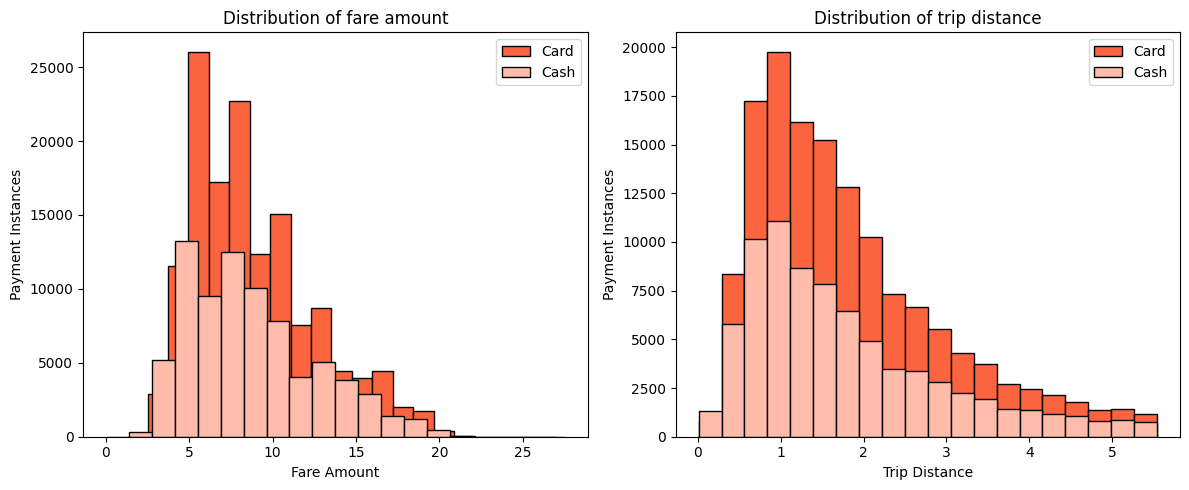

In [172]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.title('Distribution of fare amount')
plt.hist(df_revenue[df_revenue['payment_type'] == 'Card']['fare_amount'], bins=20, histtype='barstacked', edgecolor='k', color='#FA643F', label='Card')
plt.hist(df_revenue[df_revenue['payment_type'] == 'Cash']['fare_amount'], bins=20, histtype='barstacked', edgecolor='k', color='#FFBCAB', label='Cash')
plt.ylabel('Payment Instances')
plt.xlabel('Fare Amount')
plt.legend()

plt.subplot(1,2,2)
plt.title('Distribution of trip distance')
plt.hist(df_revenue[df_revenue['payment_type'] == 'Card']['trip_distance'], bins=20, histtype='barstacked', edgecolor='k', color='#FA643F', label='Card')
plt.hist(df_revenue[df_revenue['payment_type'] == 'Cash']['trip_distance'], bins=20, histtype='barstacked', edgecolor='k', color='#FFBCAB', label='Cash')
plt.ylabel('Payment Instances')
plt.xlabel('Trip Distance')
plt.legend()

plt.tight_layout()

plt.show()

In [173]:
df_revenue.groupby(by='payment_type').agg({'trip_distance':['mean', 'std', 'var'], 'fare_amount': ['mean', 'std', 'var']})

trip_distance                     fare_amount            \
                      mean       std       var        mean       std   
payment_type                                                           
Card               1.82871  1.141079  1.302061    8.845587  3.691764   
Cash               1.77355  1.184647  1.403389    8.788743  3.801562   

                         
                    var  
payment_type             
Card          13.629118  
Cash          14.451874

#### Visualizing the cash and card payments percentages

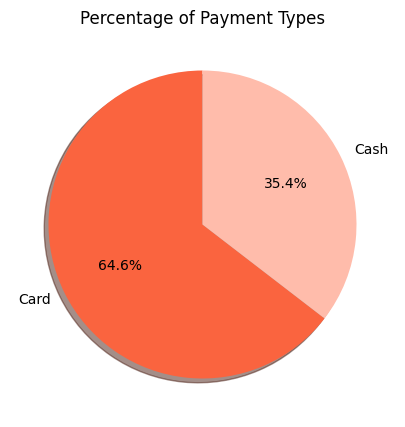

In [174]:
plt.title('Percentage of Payment Types')
plt.pie(df_revenue['payment_type'].value_counts(normalize = True), labels=df_revenue['payment_type'].value_counts(normalize = True).index,
        startangle=90, shadow=True, autopct='%1.1f%%', colors=['#FA643F', '#FFBCAB'])
plt.show()

#### Visualizing the passenger count and their payment criteria

In [175]:
passenger_payments = df_revenue.groupby(by=['payment_type', 'passenger_count'])[['passenger_count']].count()
passenger_payments.rename(columns = {'passenger_count': 'payment_type_count'}, inplace=True)
passenger_payments.reset_index(inplace=True)
passenger_payments

,payment_type,passenger_count,payment_type_count
0,Card,1,99443
1,Card,2,25458
2,Card,3,7092
3,Card,4,3558
4,Card,5,5634
5,Cash,1,52036
6,Cash,2,14380
7,Cash,3,4713
8,Cash,4,3333
9,Cash,5,3041


In [176]:
passenger_payments['payment_type_percentage'] = (passenger_payments['payment_type_count']/passenger_payments['payment_type_count'].sum())*100
passenger_payments

,payment_type,passenger_count,payment_type_count,payment_type_percentage
0,Card,1,99443,45.472545
1,Card,2,25458,11.641242
2,Card,3,7092,3.242976
3,Card,4,3558,1.626975
4,Card,5,5634,2.576273
5,Cash,1,52036,23.794630
6,Cash,2,14380,6.575578
7,Cash,3,4713,2.155125
8,Cash,4,3333,1.524089
9,Cash,5,3041,1.390566


In [177]:
passenger_payments['passenger_count'] = passenger_payments['passenger_count'].astype('int64')
passenger_payments

,payment_type,passenger_count,payment_type_count,payment_type_percentage
0,Card,1,99443,45.472545
1,Card,2,25458,11.641242
2,Card,3,7092,3.242976
3,Card,4,3558,1.626975
4,Card,5,5634,2.576273
5,Cash,1,52036,23.794630
6,Cash,2,14380,6.575578
7,Cash,3,4713,2.155125
8,Cash,4,3333,1.524089
9,Cash,5,3041,1.390566


In [178]:
cols = ['payment_type', 1,2,3,4,5]
payments_stats = pd.DataFrame(columns = cols)
payments_stats['payment_type'] = ['Card', 'Cash']
payments_stats.iloc[0,1:] = passenger_payments.iloc[0:5, -1]
payments_stats.iloc[1,1:] = passenger_payments.iloc[5:,-1]
payments_stats

,payment_type,1,2,3,4,5
0,Card,45.472545,11.641242,3.242976,1.626975,2.576273
1,Cash,23.79463,6.575578,2.155125,1.524089,1.390566


In [179]:
payments_stats = payments_stats.astype({
    'payment_type':'string',
    1: 'float64',
    2: 'float64',
    3: 'float64',
    4: 'float64',
    5: 'float64',
})
payments_stats

,payment_type,1,2,3,4,5
0,Card,45.472545,11.641242,3.242976,1.626975,2.576273
1,Cash,23.794630,6.575578,2.155125,1.524089,1.390566


In [180]:
colors=['#FA643F', '#FFBCAB']
stacked_colors = ['#FA643F', '#FFBCAB', '#CBB2B2', '#F1F1F1', '#FD9F9F']
colors, stacked_colors

(['#FA643F', '#FFBCAB'],
 ['#FA643F', '#FFBCAB', '#CBB2B2', '#F1F1F1', '#FD9F9F'])

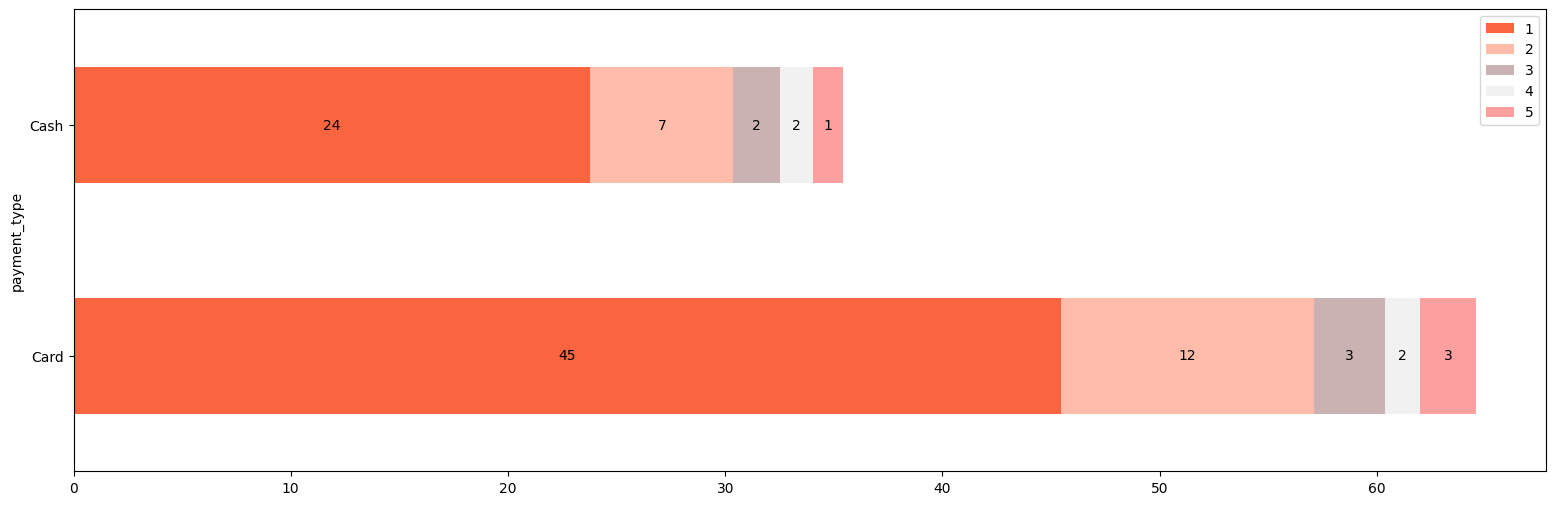

In [181]:
_, ax = plt.subplots(figsize=(19,6))
payments_stats.plot(kind='barh', x='payment_type', ax = ax, color = stacked_colors, stacked=True)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(
        x + width / 2,
        y + height / 2,
        '{:.00f}'.format(width),
        horizontalalignment='center',
        verticalalignment='center',
    )
plt.show()

#### Normality check of fare amount

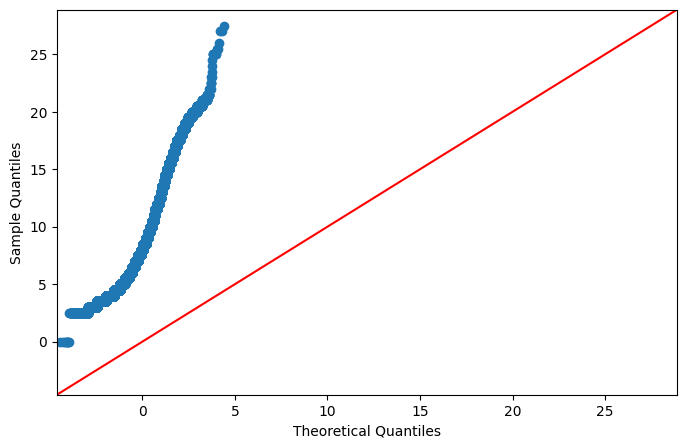

In [182]:
sm.qqplot(df_revenue['fare_amount'], line='45')
plt.show()

### Testing hypothesis

#### Hypotheses
* **Null hypothesis:** There's no difference between the cash and card payment for the acquired fare amount.
* **Alternate hypothesis:** There's a difference between the cash and card payment for the acquired fare amount.

#### Testing hypothesis

In [183]:
cash_payment_fare = df_revenue[df_revenue['payment_type'] == 'Cash']['fare_amount']
card_payment_fare = df_revenue[df_revenue['payment_type'] == 'Card']['fare_amount']

t_stats, p_value = st.ttest_ind(a=cash_payment_fare, b=card_payment_fare, equal_var=False)
t_stats, p_value

(np.float64(-3.3790498307740413), np.float64(0.0007275465904050576))

In [184]:
man_whitney_res = st.mannwhitneyu(x=cash_payment_fare.values, y=card_payment_fare.values)
man_whitney_res.statistic, man_whitney_res.pvalue

(np.float64(5388750852.0), np.float64(5.2248050013990465e-09))

#### Hypotheses testing with `ttest_ind` result
The result of your **t-test** produced two key values:

1. **T-statistic**: `-114.69` (rounded)
2. **P-value**: `0.0`

Here’s what they mean in the context of your hypothesis test:

#### 1. **T-statistic (-114.69)**:
   - The **t-statistic** measures how many standard deviations the difference between the two sample means is from zero. A very large absolute t-value (like -114.69) indicates a significant difference between the means of the two groups.
   - The negative sign simply indicates that the **mean fare amount** for cash payments is **lower** than the mean fare amount for card payments.
   - In this case, the t-statistic is extremely negative, implying a **very large difference** between the two groups (cash and card payments).

#### 2. **P-value (0.0)**:
   - The **p-value** represents the probability of observing such a large (or extreme) difference between the sample means if the null hypothesis were true.
   - A **p-value of 0.0** indicates that the likelihood of observing the difference between cash and card payments purely by chance is essentially zero. This means the difference is statistically significant.

#### Interpretation:

- **Null hypothesis (H₀)**: "There is no difference between the mean fare amounts of cash and card payments."
- **Alternative hypothesis (H₁)**: "There is a difference between the mean fare amounts of cash and card payments."

Since the **p-value is 0.0**, which is smaller than any typical significance level (e.g., 0.05 or 0.01), you would **reject the null hypothesis**.

This means:
- **There is a statistically significant difference between the mean fare amounts for cash and card payments**.
- Given the **negative t-statistic**, the result suggests that **cash payments tend to have lower fare amounts** than card payments.

### Practical Implication:
The **difference in means** between the fare amounts paid with cash versus card is statistically significant, and the test strongly suggests that customers paying with cash tend to have lower fare amounts compared to those paying with cards.

#### Hypothesis testing result with `mannwhitneyu`
The result obtained from the Mann-Whitney U test provides two key values:

1. **Test statistic**: `2167199935467.0`
2. **P-value**: `0.0`

Here’s what they mean in the context of your hypothesis test:

#### 1. **Test Statistic (2167199935467.0)**:
   - The test statistic is a measure of the rank-sum differences between the two groups (cash and card payments). It's a non-parametric test, so instead of comparing means directly, it compares the ranks of the values in both groups.
   - While the exact value of the test statistic isn't of primary interest for decision-making, its magnitude typically grows with larger datasets, and it plays a role in determining the p-value. In this case, the very large statistic suggests substantial differences in the ranks of fare amounts between the two groups.

#### 2. **P-value (0.0)**:
   - The p-value tells you how likely it is that you would observe the data (or something more extreme) if the **null hypothesis** were true.
   - A p-value of `0.0` essentially means that, given the data, the probability of observing the difference between cash and card payments purely by chance is **extremely low** (close to zero).

#### Interpreting the Results:
   - **Null hypothesis**: "There's no difference between cash and card payments for the acquired fare amount."
   - **Alternative hypothesis**: "There is a difference between cash and card payments for the acquired fare amount."

Since the **p-value is 0.0**, which is much smaller than any common significance level (e.g., 0.05 or 0.01), you **reject the null hypothesis**. This means:
   - There is strong evidence to conclude that there **is a statistically significant difference** between the fare amounts paid by cash and by card.

### Notes:
- As with the Mann-Whitney U test, you should consider the practical significance of this result, especially since the sample size is likely large, making it easier to detect statistically significant results even with small differences in fare amounts.
- You might also want to visualize the distributions or summary statistics (like the mean and standard deviation) for each payment type to gain more insights into the nature of the difference.

Both tests (Mann-Whitney and t-test) confirm a significant difference between cash and card payments, but the t-test gives you information specifically about the means of the two distributions.

In [185]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration_minutes
0,1,2020-01-01 00:28:15,2020-01-01 00:33:03,1,1.20,1,N,238,239,Card,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,0 days 00:00:04.800000
1,1,2020-01-01 00:35:39,2020-01-01 00:43:04,1,1.20,1,N,239,238,Card,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,0 days 00:00:07.416666666
2,1,2020-01-01 00:47:41,2020-01-01 00:53:52,1,0.60,1,N,238,238,Card,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,0 days 00:00:06.183333333
3,1,2020-01-01 00:55:23,2020-01-01 01:00:14,1,0.80,1,N,238,151,Card,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,0 days 00:00:04.850000
4,2,2020-01-01 00:01:58,2020-01-01 00:04:16,1,0.00,1,N,193,193,Cash,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,0 days 00:00:02.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283798,2,2020-01-02 18:21:10,2020-01-02 18:43:39,1,4.19,1,N,13,230,Cash,18.5,1.0,0.5,0.00,0.0,0.3,22.80,2.5,0 days 00:00:22.483333333
283799,2,2020-01-02 18:54:09,2020-01-02 19:09:04,1,1.54,1,N,230,143,Cash,11.0,1.0,0.5,0.00,0.0,0.3,15.30,2.5,0 days 00:00:14.916666666
283801,2,2020-01-02 18:31:07,2020-01-02 18:40:08,1,0.95,1,N,163,142,Card,7.0,1.0,0.5,1.10,0.0,0.3,12.40,2.5,0 days 00:00:09.016666666
283802,2,2020-01-02 18:42:27,2020-01-02 18:46:51,1,0.70,1,N,142,143,Cash,5.0,1.0,0.5,0.00,0.0,0.3,9.30,2.5,0 days 00:00:04.400000


## Saving the cleaned dataset

In [186]:
import os
os.makedirs('data', exist_ok=True)
df_revenue.to_csv('data/cleaned_yellow_tripdata_2020_01.csv')

In [187]:
cat data/cleaned_yellow_tripdata_2020_01.csv | head -n 100

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,6.0,1.2,0 days 00:00:04.800000
1,1,Card,7.0,1.2,0 days 00:00:07.416666666
2,1,Card,6.0,0.6,0 days 00:00:06.183333333
3,1,Card,5.5,0.8,0 days 00:00:04.850000
5,1,Cash,2.5,0.03,0 days 00:00:00.883333333
9,2,Card,8.0,0.7,0 days 00:00:11.450000
10,2,Card,12.0,2.4,0 days 00:00:16.866666666
11,1,Cash,9.5,0.8,0 days 00:00:14.433333333
13,1,Card,6.0,1.07,0 days 00:00:05.616666666
15,3,Cash,9.0,1.6,0 days 00:00:11.516666666
16,1,Card,4.0,0.5,0 days 00:00:03.033333333
17,1,Cash,11.5,1.7,0 days 00:00:16.933333333
20,1,Card,9.5,1.5,0 days 00:00:13.100000
22,1,Card,10.5,1.9,0 days 00:00:14.866666666
23,1,Card,18.0,4.2,0 days 00:00:23.750000
24,2,Card,7.5,1.5,0 days 00:00:07.900000
25,1,Card,5.5,0.6,0 days 00:00:05.583333333
27,1,Card,9.0,2.12,0 days 00:00:09.683333333
28,2,Card,5.5,0.93,0 days 00:00:05.850000
30,1,Cash,6.5,1.2,0 days 00:00:06.333333333
31,1,Card,8.5,1.3,0 days 00:00:11
32,1,Card,6.5,0.7,0 days 00:00:08.216666

In [188]:
df_xls = pd.read_csv('data/cleaned_yellow_tripdata_2020_01.csv')
df_xls

,Unnamed: 0,passenger_count,payment_type,fare_amount,trip_distance,duration
0,0,1,Card,6.0,1.20,0 days 00:00:04.800000
1,1,1,Card,7.0,1.20,0 days 00:00:07.416666666
2,2,1,Card,6.0,0.60,0 days 00:00:06.183333333
3,3,1,Card,5.5,0.80,0 days 00:00:04.850000
4,5,1,Cash,2.5,0.03,0 days 00:00:00.883333333
...,...,...,...,...,...,...
218683,283797,1,Card,10.0,2.02,0 days 00:00:11.266666666
218684,283798,1,Cash,18.5,4.19,0 days 00:00:22.483333333
218685,283799,1,Cash,11.0,1.54,0 days 00:00:14.916666666
218686,283801,1,Card,7.0,0.95,0 days 00:00:09.016666666


In [189]:
df_xls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218688 entries, 0 to 218687
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       218688 non-null  int64  
 1   passenger_count  218688 non-null  int64  
 2   payment_type     218688 non-null  object 
 3   fare_amount      218688 non-null  float64
 4   trip_distance    218688 non-null  float64
 5   duration         218688 non-null  object 
dtypes: float64(2), int64(2), object(2)
memory usage: 10.0+ MB


## Prepare Dataset

In [196]:
# Re-initialize df from the raw data and apply necessary preprocessing
df = pd.read_csv('/content/yellow_tripdata_2020-01.csv')

# Apply type conversions (from uOLKK1tYElms)
type_mappings = {
    'tpep_pickup_datetime': 'datetime64[ns]',
    'tpep_dropoff_datetime': 'datetime64[ns]',
    'store_and_fwd_flag': 'string',
}
df = df.astype(type_mappings)

# Fill NaNs for categorical columns (from rbd_rRbzElmw)
df['VendorID'].fillna(df['VendorID'].mode()[0], inplace=True)
df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)
df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)
df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0], inplace=True)
df['payment_type'].fillna(df['payment_type'].mode()[0], inplace=True)

# Filter passenger count and payment type (from 9dcm9PxWElmx)
df = df[(df['passenger_count'] < 6) & (df['passenger_count'] > 0)]
df = df[df['payment_type'] < 3]

# Convert payment_type to strings (from 9UvQvzljElmy)
df['payment_type'].replace([1.0, 2.0], ['Card', 'Cash'], inplace=True)

# Now, proceed with the original logic of x9lrqAPrGCZg
df = df[['payment_type','fare_amount','total_amount','tip_amount']]

# Drop rows where any of the key financial columns are NaN
df.dropna(subset=['fare_amount', 'total_amount', 'tip_amount'], inplace=True)

df = df[df['total_amount'] > 0]

# Adjust mapping for payment_type as it already contains string values ('Card', 'Cash')
df['payment_type'] = df['payment_type'].map({'Card':'Credit Card','Cash':'Cash'})

# Remove extreme outliers
upper = df['total_amount'].quantile(0.99)
df = df[df['total_amount'] <= upper]

df.head()

,payment_type,fare_amount,total_amount,tip_amount
0,Credit Card,6.0,11.27,1.47
1,Credit Card,7.0,12.30,1.50
2,Credit Card,6.0,10.80,1.00
3,Credit Card,5.5,8.16,1.36
4,Cash,3.5,4.80,0.00


## Logistic Regression: Predict High-Fare Trips

In [197]:
# Define high fare as top 25%
threshold = df['total_amount'].quantile(0.75)
df['high_fare'] = (df['total_amount'] >= threshold).astype(int)

# Encode payment type
df['payment_binary'] = df['payment_type'].map({'Credit Card':1,'Cash':0})

X = df[['payment_binary','fare_amount','tip_amount']]
y = df['high_fare']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

pred = model.predict(X_test)
print(classification_report(y_test,pred))
print('ROC-AUC:', roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    208621
           1       0.98      0.98      0.98     70426

    accuracy                           0.99    279047
   macro avg       0.99      0.99      0.99    279047
weighted avg       0.99      0.99      0.99    279047

ROC-AUC: 0.9990324357089081


## Logistic Regression Coefficients

In [198]:
coefficients = pd.DataFrame({'Feature':X.columns,'Coefficient':model.coef_[0]})
coefficients

,Feature,Coefficient
0,payment_binary,0.109813
1,fare_amount,2.663256
2,tip_amount,2.661000


## Revenue Uplift Simulation Model

In [199]:
# Current average revenue
avg_credit = df[df['payment_type']=='Credit Card']['total_amount'].mean()
avg_cash = df[df['payment_type']=='Cash']['total_amount'].mean()

current_credit_ratio = (df['payment_type']=='Credit Card').mean()

# Simulate 10% shift from cash to credit
new_credit_ratio = current_credit_ratio + 0.10

current_revenue = df['total_amount'].mean()
simulated_revenue = (new_credit_ratio * avg_credit) + ((1-new_credit_ratio) * avg_cash)

uplift = simulated_revenue - current_revenue

current_revenue, simulated_revenue, uplift

(np.float64(18.099022485499734),
 np.float64(18.458256966776297),
 np.float64(0.35923448127656243))

## A/B Testing Framework for Payment Nudging

Simulate two groups:
- Control: No incentive
- Treatment: Digital payment incentive

In [200]:
# Simulate uplift effect
np.random.seed(42)

control = np.random.normal(loc=current_revenue, scale=5, size=1000)
treatment = np.random.normal(loc=current_revenue+uplift, scale=5, size=1000)

t_stat, p_val = stats.ttest_ind(treatment, control)
t_stat, p_val

(np.float64(2.790649026320465), np.float64(0.005310223830178448))

## A/B Test Distribution Comparison

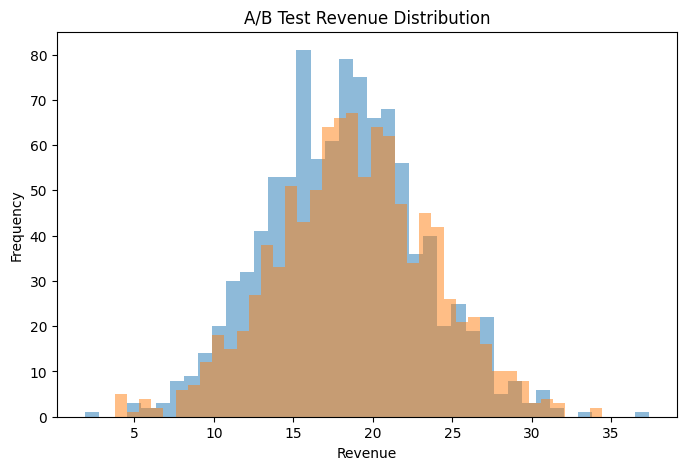

In [201]:
plt.figure()
plt.hist(control, bins=40, alpha=0.5)
plt.hist(treatment, bins=40, alpha=0.5)
plt.title('A/B Test Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

## Driver Revenue Impact Analysis

In [202]:
driver_impact = df.groupby('payment_type')['total_amount'].agg(['mean','sum','count'])
driver_impact

,mean,sum,count
payment_type,,,
Cash,15.638004,4580856.25,292931
Credit Card,19.230349,12254040.01,637224


## Visualization: Average Revenue by Payment Type

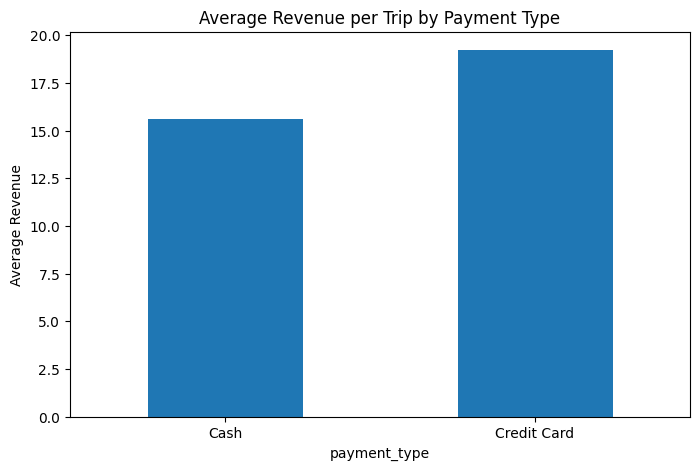

In [203]:
plt.figure()
df.groupby('payment_type')['total_amount'].mean().plot(kind='bar')
plt.title('Average Revenue per Trip by Payment Type')
plt.ylabel('Average Revenue')
plt.xticks(rotation=0)
plt.show()

| Platform     | Profile Link                                   |
|--------------|-----------------------------------------------|
| LinkedIn     | [Priya Pal](www.linkedin.com/in/priya-pal-72346b251) |
| GitHub       | [PriyaPal](https://github.com/Priyapal15)      |